In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [4]:
import yfinance as yf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.data.ingest import download_prices, clean_prices, build_universe

In [5]:
cache = Path("../data/raw/prices.parquet")
tickers = build_universe()
raw_df = download_prices(tickers, cache)
clean_df, report = clean_prices(raw_df)

returns = clean_df["Close"].pct_change(fill_method=None)
equity_returns = returns.drop(columns=["^FTSE", "^VIX"])
benchmark_returns = returns["^FTSE"]
vix = clean_df["Close"]["^VIX"]

print(f"Equity returns shape: {equity_returns.shape}")


Loading cached data from ../data/raw/prices.parquet
Dropping 7 tickers: ['AAF.L', 'CCEP.L', 'EDV.L', 'HLN.L', 'MNG.L', 'MTLN.L', 'PSH.L']
Equity returns shape: (2919, 93)


In [17]:
stats = pd.DataFrame({
    "mean":  equity_returns.mean(),
    "std":   equity_returns.std(),
    "skew":  equity_returns.skew(),
    "kurt":  equity_returns.kurt()
})
print(stats)


            mean       std      skew       kurt
Ticker                                         
AAL.L   0.000825  0.028690  0.220749   6.364825
ABF.L  -0.000044  0.017214  0.070623  14.242415
ADM.L   0.000421  0.015229 -0.726988  14.738911
ALW.L   0.000397  0.010372 -0.170799   8.483892
ANTO.L  0.000873  0.024832  0.351194   2.666583
...          ...       ...       ...        ...
ULVR.L  0.000226  0.012522  0.560742  10.727913
UU.L    0.000247  0.014349 -0.002103   4.321291
VOD.L  -0.000086  0.015846 -0.101040   5.667465
WEIR.L  0.000340  0.021976 -0.069761   4.974401
WTB.L   0.000014  0.019583  0.137313   9.148424

[93 rows x 4 columns]


In [19]:
stats["kurt"].mean().round(2)

np.float64(15.75)

In [18]:
stats.to_csv("../data/processed/return_stats.csv")


In [27]:
stats.nlargest(3, "mean").index.tolist()      # top 3 by mean
stats.nsmallest(2, "skew").index.tolist()     # most negative skew
print(stats.nlargest(3, "mean").index.tolist())
print(stats.nsmallest(2, "skew").index.tolist())

['GAW.L', 'DPLM.L', 'PCT.L']
['IGG.L', 'BNZL.L']


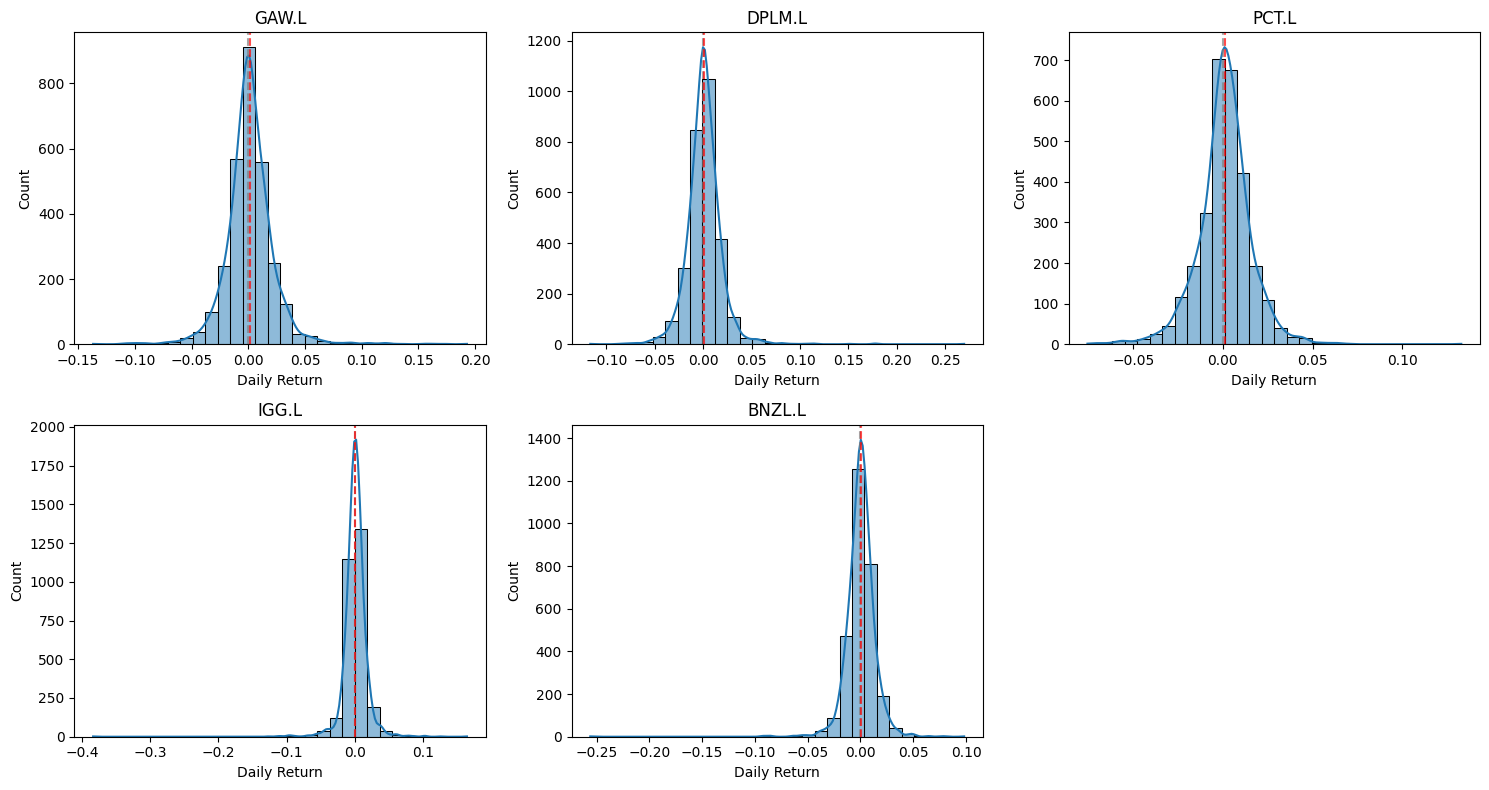

In [33]:
selected = ['GAW.L', 'DPLM.L', 'PCT.L', 'IGG.L', 'BNZL.L']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, ticker in enumerate(selected):
    sns.histplot(returns[ticker], ax=axes[i], kde=True, bins=30)
    axes[i].axvline(0, color='grey', linestyle='--', alpha=0.7)
    axes[i].axvline(returns[ticker].mean(), color='red', linestyle='--', alpha=0.7)

    axes[i].set_title(ticker)
    axes[i].set_xlabel("Daily Return")
    axes[-1].set_visible(False)


plt.tight_layout()
plt.show()


In [31]:
equity_returns["IGG.L"].nsmallest(5)


Date
2016-12-06   -0.383609
2018-09-27   -0.127072
2020-03-23   -0.114986
2021-09-02   -0.110053
2020-07-23   -0.107914
Name: IGG.L, dtype: float64

In [32]:
print(stats.loc["GAW.L"])


mean    0.001488
std     0.021569
skew    0.879740
kurt    9.940110
Name: GAW.L, dtype: float64


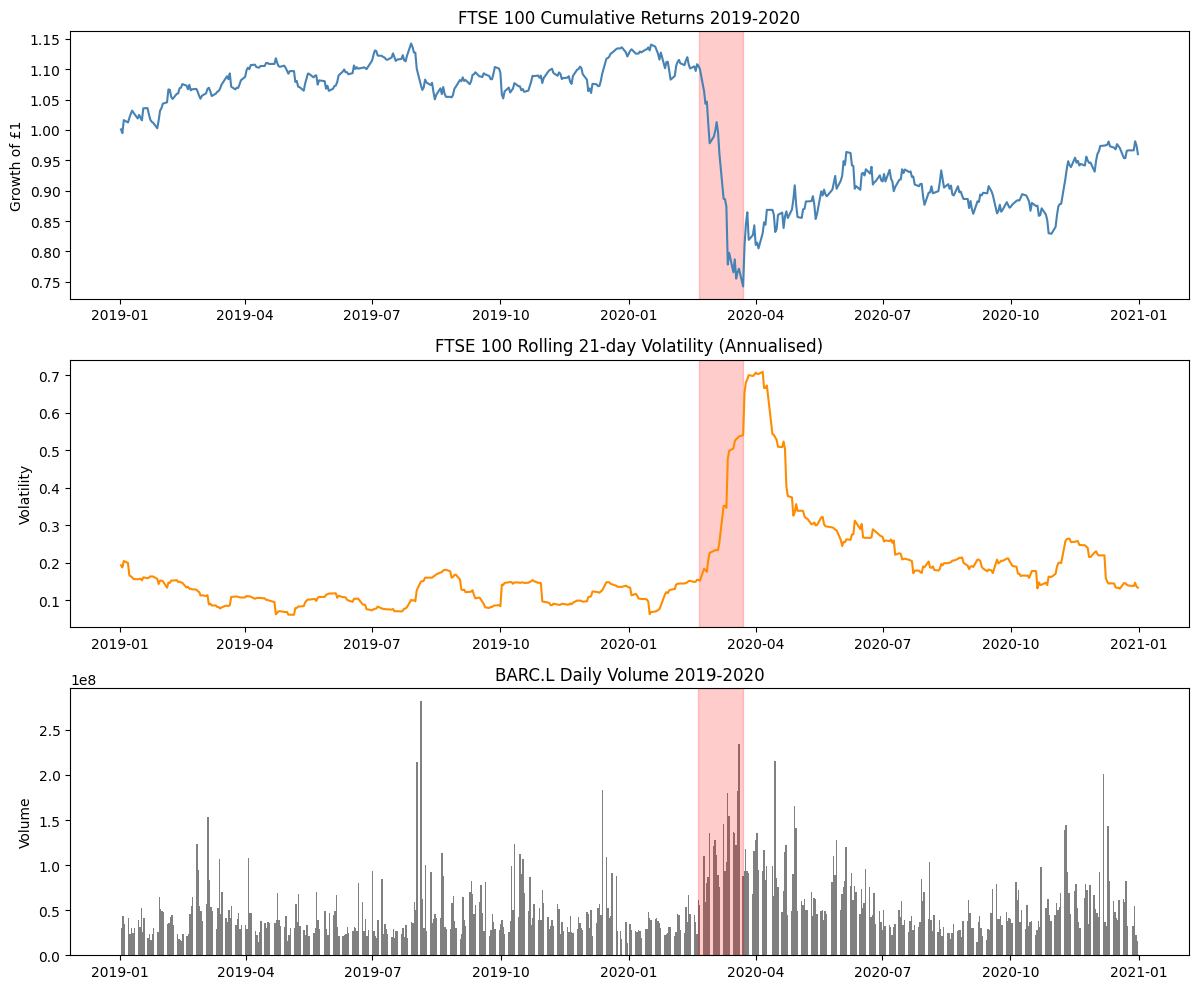

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1 - FTSE 100 cumulative returns
covid_returns = benchmark_returns["2019-01-01":"2020-12-31"]
cumulative = (1 + covid_returns).cumprod()
axes[0].plot(cumulative.index, cumulative.values, color="steelblue")
axes[0].set_title("FTSE 100 Cumulative Returns 2019-2020")
axes[0].set_ylabel("Growth of £1")
axes[0].axvspan("2020-02-20", "2020-03-23", alpha=0.2, color="red")

# Plot 2 - rolling 21-day volatility
rolling_vol = benchmark_returns.rolling(21).std() * (252 ** 0.5)  # annualised
rolling_vol_window = rolling_vol["2019-01-01":"2020-12-31"]
axes[1].plot(rolling_vol_window.index, rolling_vol_window.values, color="darkorange")
axes[1].set_title("FTSE 100 Rolling 21-day Volatility (Annualised)")
axes[1].set_ylabel("Volatility")
axes[1].axvspan("2020-02-20", "2020-03-23", alpha=0.2, color="red")

# Plot 3 - BARC.L volume
covid_volume = clean_df["Volume"]["BARC.L"]["2019-01-01":"2020-12-31"]
axes[2].bar(covid_volume.index, covid_volume.values, color="grey", width=1)
axes[2].set_title("BARC.L Daily Volume 2019-2020")
axes[2].set_ylabel("Volume")
axes[2].axvspan("2020-02-20", "2020-03-23", alpha=0.2, color="red")

plt.tight_layout()
plt.show()


Mean pairwise correlation: 0.295
Min correlation:    0.001
Max correlation:    0.882
% pairs above 0.5: 5.2%


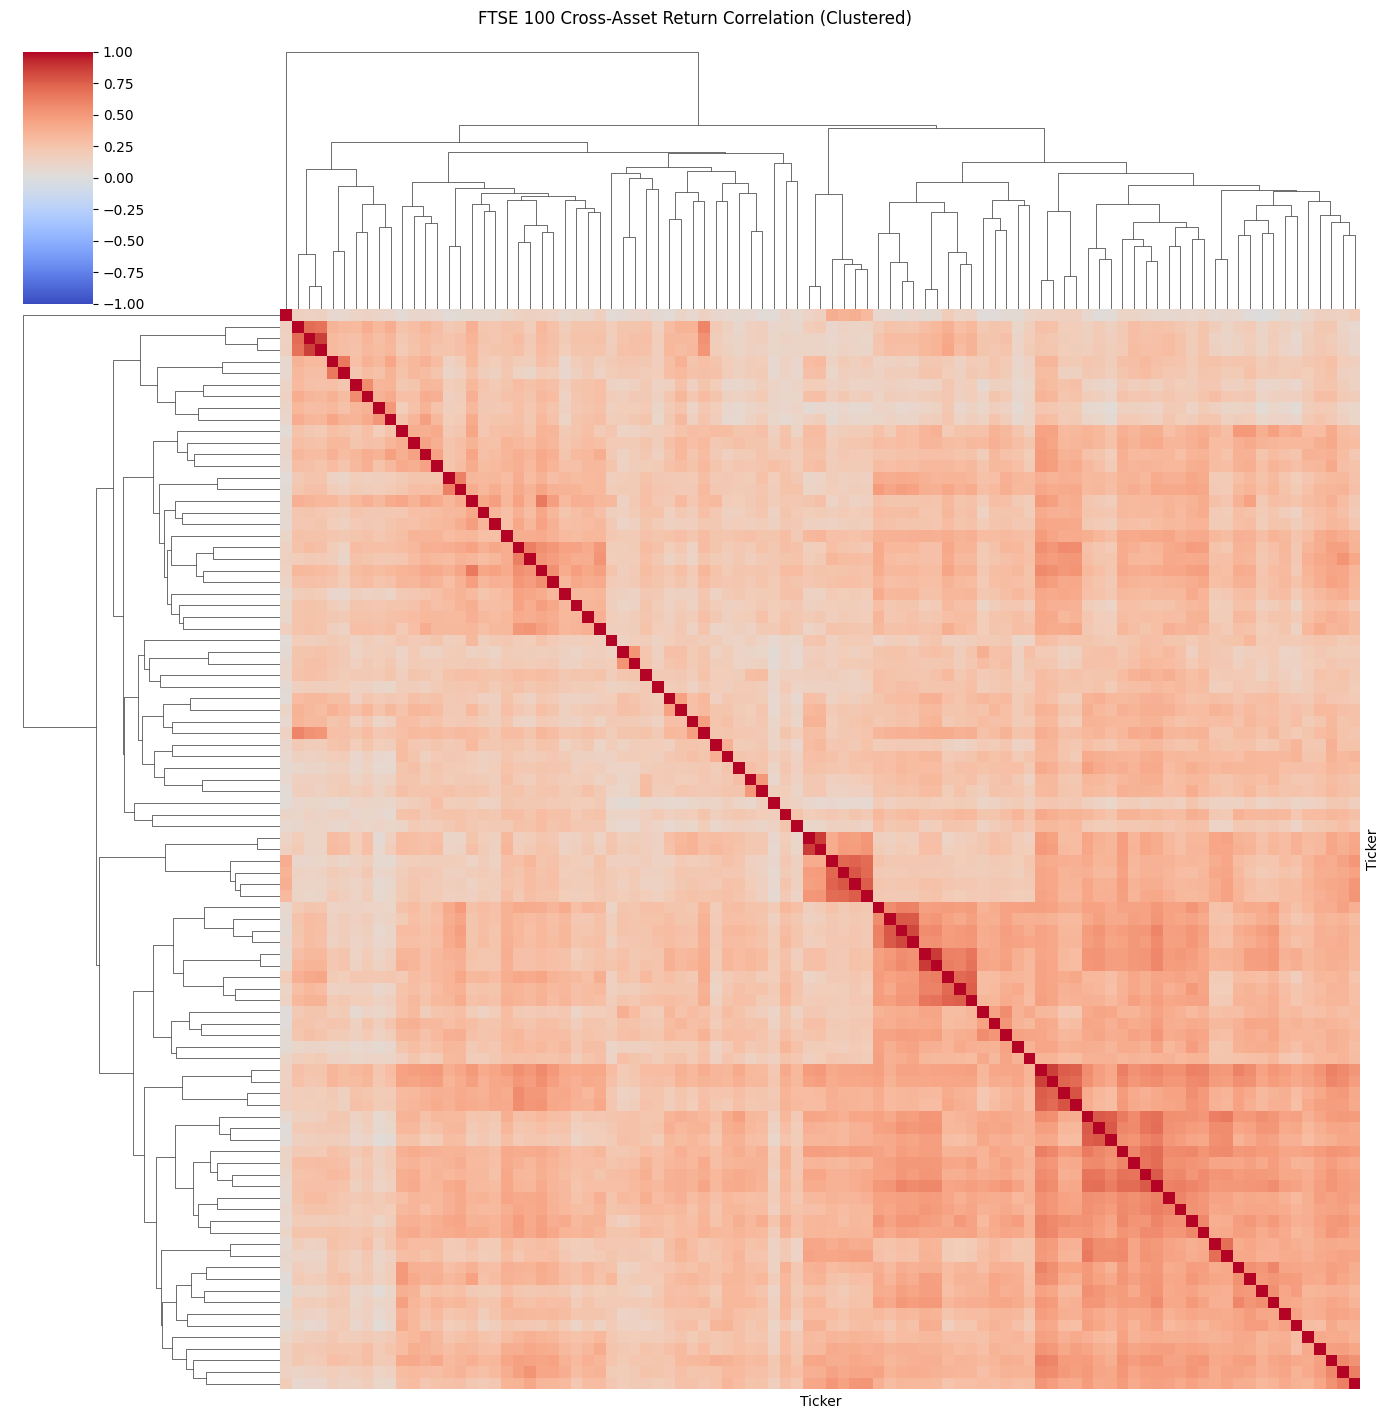

In [35]:


# 1. Compute correlation matrix
corr_matrix = equity_returns.corr()

# 2. Mean pairwise correlation (excluding diagonal)
corr_values = corr_matrix.values.copy()
np.fill_diagonal(corr_values, np.nan)  # exclude self-correlation
mean_corr = np.nanmean(corr_values)
print(f"Mean pairwise correlation: {mean_corr:.3f}")

# 3. Distribution of pairwise correlations
upper_triangle = corr_values[np.triu_indices_from(corr_values, k=1)]
print(f"Min correlation:    {upper_triangle.min():.3f}")
print(f"Max correlation:    {upper_triangle.max():.3f}")
print(f"% pairs above 0.5: {(upper_triangle > 0.5).mean() * 100:.1f}%")

# 4. Clustermap
sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(14, 14),
    xticklabels=False,
    yticklabels=False,
    vmin=-1, vmax=1
)
plt.suptitle("FTSE 100 Cross-Asset Return Correlation (Clustered)", y=1.01)
plt.show()


In [36]:
# Find the most correlated pair
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]  # remove self-correlations
print(corr_unstacked.idxmax())
print(corr_unstacked.max())


('BLND.L', 'LAND.L')
0.8824052605760289
